In [1]:
# script to plot correlations between dnase allele specific effects and mpra skew

In [2]:
# import packages
import pandas as pd
pd.options.mode.chained_assignment = None
import os
from tqdm import tqdm
from scipy import stats
import torch
import matplotlib.pyplot as mpl
import seaborn as sns
import numpy as np
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from collections import Counter
import matplotlib

In [3]:
# Open empirical data
# hepg2
hepg2_dnase = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/Benchmarking_Sets/Vierstra/CAV_Calls/HepG2.aggregation.bed',
                          sep = '\t')
# filter for only SNPs
hepg2_mask = (hepg2_dnase['ref'].str.len() == 1) & (hepg2_dnase['alt'].str.len() == 1)
hepg2_dnase = hepg2_dnase.loc[hepg2_mask]

# k562
k562_dnase = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/Benchmarking_Sets/Vierstra/CAV_Calls/K562.aggregation.bed',
                         sep = '\t')
# filter for only SNPs
k562_mask = (k562_dnase['ref'].str.len() == 1) & (k562_dnase['alt'].str.len() == 1)
k562_dnase = k562_dnase.loc[k562_mask]
# Add ID in tewhey format to each DNase DF
hepg2_dnase.loc[:,]['id'] = [(':').join([i,str(j),k,l]) for i,j,k,l in zip(hepg2_dnase['#chr'],
                                                                           hepg2_dnase['end'],
                                                                           hepg2_dnase['ref'],
                                                                           hepg2_dnase['alt'])]
k562_dnase.loc[:,]['id'] = [(':').join([i,str(j),k,l]) for i,j,k,l in zip(k562_dnase['#chr'],
                                                                          k562_dnase['end'],
                                                                          k562_dnase['ref'],
                                                                          k562_dnase['alt'])]

In [4]:
# filter DNase assay for significant hits
# hepg2
hepg2_dnase_ase = hepg2_dnase[hepg2_dnase['min_fdr'] <= .05]
# k562
k562_dnase_ase = k562_dnase[k562_dnase['min_fdr'] <= .05]

In [5]:
# open merged mpra data/predictions
mpra_emp_and_preds = pd.read_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/ukbb_gtex_mpra/final_datasets/all_ukbb_gtex_preds_merge_with_controls.tsv',
                                 sep = '\t',
                                 low_memory=False)

In [6]:
# filter empirical data for each cell type and merge with DNase ASE variants
# k562
k562_merge = k562_dnase_ase.merge(mpra_emp_and_preds[mpra_emp_and_preds['cell_type'] == 'K562'], on='id')
# refactor dnase skew to match alt - ref
k562_merge['es_refactor'] = [-1*i for i in k562_merge['es_mean']]
# hepg2
hepg2_merge = hepg2_dnase_ase.merge(mpra_emp_and_preds[mpra_emp_and_preds['cell_type'] == 'HEPG2'], on='id')
# refactor dnase skew
hepg2_merge['es_refactor'] = [-1*i for i in hepg2_merge['es_mean']]

In [7]:
# split DFs into emVars and non-emVars
### k562 ###
k_merge_emvar = k562_merge[k562_merge['emVar'] == True]
k_merge_neg = k562_merge[~k562_merge['emVar'] == True]
### hepg2 ###
h_merge_emvar = hepg2_merge[hepg2_merge['emVar'] == True]
h_merge_neg = hepg2_merge[~hepg2_merge['emVar'] == True]
# calculate pearson correlations for DNase scatter
# k562
k_emvar_corr = round(stats.pearsonr(x=k_merge_emvar['es_refactor'], y=k_merge_emvar['Log2Skew'])[0], 2)
print('k562 emvar p-value:', stats.pearsonr(x=k_merge_emvar['es_refactor'], y=k_merge_emvar['Log2Skew'])[1])
k_neg_corr = round(stats.pearsonr(x=k_merge_neg['es_refactor'], y=k_merge_neg['Log2Skew'])[0], 2)
k_all_corr = round(stats.pearsonr(x=k562_merge['es_refactor'], y=k562_merge['Log2Skew'])[0], 2)
print('k526 all p-value:', stats.pearsonr(x=k562_merge['es_refactor'], y=k562_merge['Log2Skew'])[1])
###
# hepg2
h_emvar_corr = round(stats.pearsonr(x=h_merge_emvar['es_refactor'], y=h_merge_emvar['Log2Skew'])[0], 2)
print('hepg2 emvar p-value', stats.pearsonr(x=h_merge_emvar['es_refactor'], y=h_merge_emvar['Log2Skew'])[1])
h_neg_corr = round(stats.pearsonr(x=h_merge_neg['es_refactor'], y=h_merge_neg['Log2Skew'])[0], 2)
h_all_corr = round(stats.pearsonr(x=hepg2_merge['es_refactor'], y=hepg2_merge['Log2Skew'])[0], 2)
print('hepg2 all p-value', stats.pearsonr(x=hepg2_merge['es_refactor'], y=hepg2_merge['Log2Skew'])[1])

k562 emvar p-value: 1.7533311956758104e-10
k526 all p-value: 1.4108287207443246e-12
hepg2 emvar p-value 8.90601917526123e-06
hepg2 all p-value 9.670508095139684e-06


In [8]:
print('k562 emVar', len(k_merge_emvar))
print('k562 non-emVar', len(k_merge_neg))
print('hepg2 emVar', len(h_merge_emvar)) 
print('hepg2 non-emVar', len(h_merge_neg))

k562 emVar 63
k562 non-emVar 112
hepg2 emVar 28
hepg2 non-emVar 31


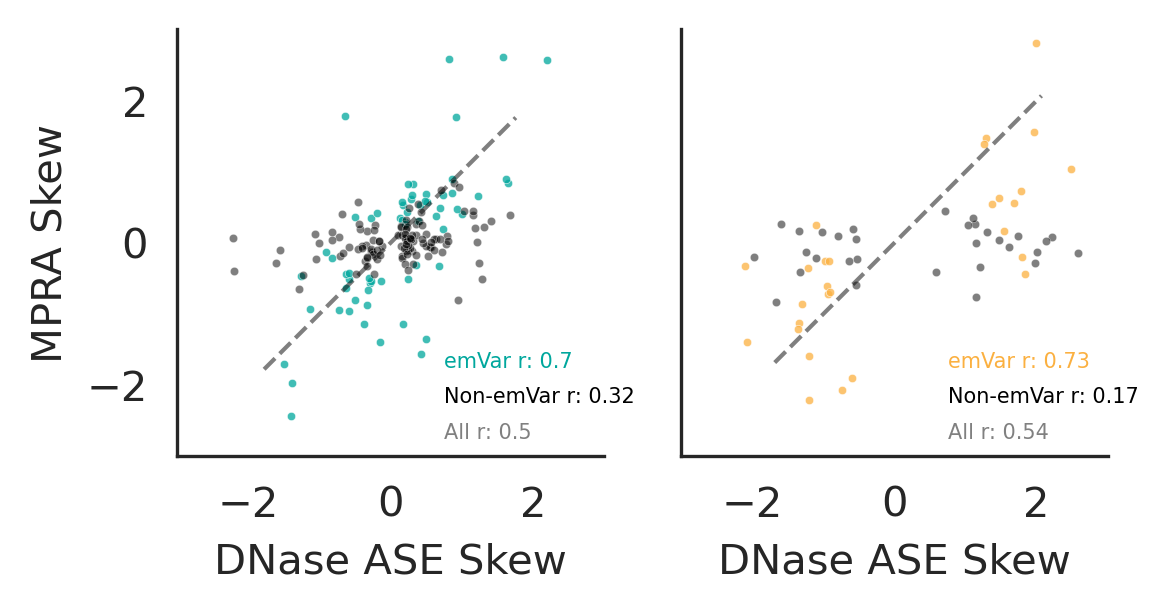

In [9]:
# plot correlation of DNase ASE variants and empirical MPRA Data
f = mpl.figure(figsize=(4,4),dpi=300)
gs = f.add_gridspec(1,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
### plot correlation of empircal MPRA with DNase ASE
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k562_merge['es_refactor'])), (.8 * max(k562_merge['es_refactor']))],
             [(.8 * min(k562_merge['es_refactor'])), (.8 * max(k562_merge['es_refactor']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_merge_emvar,
                    x='es_refactor',
                    y='Log2Skew',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_merge_neg,
                    x='es_refactor',
                    y='Log2Skew',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlabel('DNase ASE Skew')
    mpl.ylabel('MPRA Skew')
    mpl.xlim(-3, 3)
    mpl.ylim(-3, 3)
    mpl.annotate(xy=(.75, -1.75), text=f'emVar r: {k_emvar_corr}', color='#00A79D', fontsize=5)
    mpl.annotate(xy=(.75, -2.25), text=f'Non-emVar r: {k_neg_corr}', color= 'k', fontsize=5)
    mpl.annotate(xy=(.75, -2.75), text=f'All r: {k_all_corr}', color='gray', fontsize=5)
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1])
    ax_02.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(hepg2_merge['es_refactor'])), (.8 * max(hepg2_merge['es_refactor']))],
             [(.8 * min(hepg2_merge['es_refactor'])), (.8 * max(hepg2_merge['es_refactor']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_merge_emvar,
                    x='es_refactor',
                    y='Log2Skew',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_merge_neg,
                    x='es_refactor',
                    y='Log2Skew',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.annotate(xy=(.75, -1.75), text=f'emVar r: {h_emvar_corr}', color='#FBB040', fontsize=5)
    mpl.annotate(xy=(.75, -2.25), text=f'Non-emVar r: {h_neg_corr}', color='k', fontsize=5)
    mpl.annotate(xy=(.75, -2.75), text=f'All r: {h_all_corr}', color='gray', fontsize=5)
    mpl.xlabel('DNase ASE Skew')
    mpl.ylabel('')
    mpl.yticks([])
    mpl.xlim(-3, 3)
    mpl.ylim(-3, 3)
sns.despine()
mpl.tight_layout()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/dnase_comparisons/k562.hepg2.dnase.ase.empirical.corr.emvar.colored.pdf')

In [11]:
def splitter (string):
    split = string[1:-1].split(',')
    float_split = [float(i) for i in split]
    return float_split

In [12]:
# define function to convert pt to DF
def pt2df (path2pt, n_preds):
    # Open predictions
    pt = torch.load(path2pt)
    # Open VCF used for generating predictions
    vcf = pt['vcf']
    # Use VCF to generate collapsed IDs chr:pos:ref:alt:INFO
    vcf_ids = [(':').join([i,str(j),k,l]) for i,j,k,l in zip(vcf['chrom'],
                                                             vcf['pos'],
                                                             vcf['ref'],
                                                             vcf['alt'])]
    # Make Dictionary of ID:number (basically index) pairs
    id_dict = dict(zip(vcf_ids, [i for i in range(0,len(vcf_ids))]))
    # Iterate over Dictionary to combine ID from VCF with predictions from Tensor
    df_rows = []
    for i in tqdm(id_dict):
        tmp = []
        # Split ID back into Chrom, Pos, Ref, Alt
        splitted = i.split(':')
        chrom = splitted[0]
        pos = splitted[1]
        ref = splitted[2]
        alt = splitted[3]
        # Make a tmp list for ref/alt each cell type
        # K562
        k562_ref_list = []
        k562_alt_list = []
        # HepG2
        hepg2_ref_list = []
        hepg2_alt_list = []
        # SK-N-SH
        sknsh_ref_list = []
        sknsh_alt_list = []
        # Iterate of each prediction
        for x in range(0, n_preds):
            # Get reference for predictions for fwd and rev strands
            ref_pred = pt['ref'][id_dict.get(i), 0, x]
            #ref_rev_comp = pt['ref'][id_dict.get(i), 1, x]
            # Take average of fwd/rev_comp predictions and add to cell type list
            k562_ref_list.append(ref_pred[0].item())
            hepg2_ref_list.append(ref_pred[1].item())
            sknsh_ref_list.append(ref_pred[2].item())
            # Get alternate predictions for fwd and rev strands
            alt_pred = pt['alt'][id_dict.get(i), 0, x]
            #alt_rev_comp = pt['alt'][id_dict.get(i), 1, x]
            # Take average of fwd/rev_comp predictions and add to cell type list
            k562_alt_list.append(alt_pred[0].item())
            hepg2_alt_list.append(alt_pred[1].item())
            sknsh_alt_list.append(alt_pred[2].item())
        # Subtract alt-ref to get skew
        k562_skew = [j-i for i,j in zip(k562_ref_list, k562_alt_list)]
        hepg2_skew = [j-i for i,j in zip(hepg2_ref_list, hepg2_alt_list)]
        sknsh_skew = [j-i for i,j in zip(sknsh_ref_list, sknsh_alt_list)]
        # Build row as tmp list
        tmp.append(chrom)
        tmp.append(pos)
        tmp.append(ref)
        tmp.append(alt)
        tmp.append(k562_ref_list)
        tmp.append(k562_alt_list)
        tmp.append(hepg2_ref_list)
        tmp.append(hepg2_alt_list)
        tmp.append(sknsh_ref_list)
        tmp.append(sknsh_alt_list)
        tmp.append(k562_skew)
        tmp.append(hepg2_skew)
        tmp.append(sknsh_skew)
        # Append tmp list to "rows" list for formatting to DF
        df_rows.append(tmp)
    col_names = ['chrom',
                 'pos',
                 'ref',
                 'alt',
                 'k562_ref_pred',
                 'k562_alt_pred',
                 'hepg2_ref_pred',
                 'hepg2_alt_pred',
                 'sknsh_ref_pred',
                 'sknsh_alt_pred',
                 'k562_skew_pred',
                 'hepg2_skew_pred',
                 'sknsh_skew_pred']
    df = pd.DataFrame(df_rows, columns=col_names)
    return df

In [13]:
def pt2df_dict (path2pts, n_preds):
    df_dict = {}
    pt_list = [i for i in os.listdir(path2pts) if i.endswith('.pt')]
    for i in pt_list:
        print(i)
        chr_key = i.split('_')[0]
        df_dict.update({chr_key : pt2df(f'{path2pts}/{i}', n_preds)})
    return df_dict

In [14]:
# store path to predictions for both cell types as variable
# hepg2
path2hepg2 = '/Users/buttsj/Dropbox (JAX)/Variant_Effects/Benchmarking_Sets/Vierstra/CAV_017_Preds/hepg2/'
# k562
path2k562 = '/Users/buttsj/Dropbox (JAX)/Variant_Effects/Benchmarking_Sets/Vierstra/CAV_017_Preds/k562/'
# Open predictions and store as DF
# hepg2
hepg2_raw_preds = pt2df_dict(path2hepg2, 
                                 18)
# k562
k562_raw_preds = pt2df_dict(path2k562, 
                                18)

hepg2.chr14.cav.017.pt


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 392/392 [00:00<00:00, 3914.56it/s]


hepg2.chr19.cav.017.pt


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 970/970 [00:00<00:00, 4031.65it/s]


hepg2.chr8.cav.017.pt


...

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1178/1178 [00:00<00:00, 3972.86it/s]


k562.chr17.cav.017.pt


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1604/1604 [00:00<00:00, 3887.20it/s]


k562.chr20.cav.017.pt


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 976/976 [00:00<00:00, 3875.02it/s]


In [15]:
# convert to DF with column of pos 100 score ref/alt, avg all 18 ref/alt, and max ref/alt
# concatenate gtex into single DF
hepg2_dnase_preds_df = pd.concat(hepg2_raw_preds.values())
# concatenate traits into single DF
k562_dnase_preds_df = pd.concat(k562_raw_preds.values())

In [16]:
# define function to add columns listed in line 119
def add_100_avg(pt_df, one_hundred_index):
    # list of column names
    col_names = ['k562_ref_pred', 'k562_alt_pred',
                 'hepg2_ref_pred', 'hepg2_alt_pred',
                 'sknsh_ref_pred', 'sknsh_alt_pred',
                 'k562_skew_pred', 'hepg2_skew_pred', 'sknsh_skew_pred']
    # add position 100
    for i in tqdm(col_names):
        pt_df.loc[:,][f'{i}_pos_100'] = [
            float(j[one_hundred_index]) for j in pt_df[i]]
    # add avg all predictions
    for i in tqdm(col_names):
        pt_df.loc[:,][f'{i}_avg'] = [np.mean(j) for j in pt_df[i]]
    return pt_df

In [17]:
# add avg and center scores to hepg2 and k562 concatenated DFs
# hepg2
hepg2_dnase_preds_df = add_100_avg(hepg2_dnase_preds_df,
                                   8)
# add ID to above DF
hepg2_dnase_preds_df.loc[:,]['id'] = [(':').join([i, str(j), k, l]) for i, j, k, l in zip(hepg2_dnase_preds_df['chrom'],
                                                                                          hepg2_dnase_preds_df['pos'],
                                                                                          hepg2_dnase_preds_df['ref'],
                                                                                          hepg2_dnase_preds_df['alt'])]
# k562
k562_dnase_preds_dff = add_100_avg(k562_dnase_preds_df,
                                   8)
# add ID to above DF
k562_dnase_preds_df.loc[:,]['id'] = [(':').join([i, str(j), k, l]) for i, j, k, l in zip(k562_dnase_preds_df['chrom'],
                                                                                         k562_dnase_preds_df['pos'],
                                                                                         k562_dnase_preds_df['ref'],
                                                                                         k562_dnase_preds_df['alt'])]
# merge vep and avg/center/raw preds df into single DF
# hepg2
hepg2_all_preds = hepg2_dnase_preds_df.copy()
# k562
k562_all_preds = k562_dnase_preds_df.copy()

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:01<00:00,  8.78it/s]


In [18]:
# merge predictions with empirical data for generating PRCs
def merge_data (dnase_df, preds_df):
    merged_df = dnase_df.merge(preds_df, how='inner', on='id')
    return merged_df

In [19]:
# merge with empirical data
# hepg2
hepg2_merge_all = merge_data(hepg2_dnase, hepg2_all_preds)
# refactor es mean to match directionality of ref/alt
hepg2_merge_all['refactor_es_mean'] = [-1 * i for i in hepg2_merge_all['es_mean']]
# k562
k562_merge_all = merge_data(k562_dnase, k562_all_preds)
# refactor es mean to match directionality of ref/alt
k562_merge_all['refactor_es_mean'] = [-1 * i for i in k562_merge_all['es_mean']]

In [20]:
# filter merged predictions for only ase variants
h_ase_preds = hepg2_merge_all[hepg2_merge_all['min_fdr'] < .05]
k_ase_preds = k562_merge_all[k562_merge_all['min_fdr'] < .05]

In [21]:
# define a function to call predicted emVars
def call_pred_emvars (merged_preds,
                      cell_type,
                      skew_threshold):
    # add emvar status for each prediction strategy
    # pos 100
    merged_preds[f'{cell_type.lower()}_pos_100_emVar'] = [1 if abs(i) > skew_threshold else 0 for i in merged_preds[f'{cell_type.lower()}_skew_pred_pos_100']]
    # average
    merged_preds[f'{cell_type.lower()}_avg_emVar'] = [1 if abs(i) > skew_threshold else 0 for i in merged_preds[f'{cell_type.lower()}_skew_pred_avg']]
    return merged_preds

In [22]:
# call emvars by MPAC
h_ase_preds_emVar_ann = call_pred_emvars(h_ase_preds,
                                         'hepg2',
                                         .5)
k_ase_preds_emVar_ann = call_pred_emvars(k_ase_preds,
                                         'K562',
                                         .5)

In [27]:
# define function to calculate pearsons for each prediction strategy
def score_pearsons (emvar_called_df,
                    cell_type):
    print(cell_type)
    # calculate pearson for all together
    all_pos_100_pearson = round(stats.pearsonr(x=emvar_called_df['refactor_es_mean'], y=emvar_called_df[f'{cell_type}_skew_pred_pos_100'])[0],2)
    print('all center')
    print(stats.pearsonr(x=emvar_called_df['refactor_es_mean'], y=emvar_called_df[f'{cell_type}_skew_pred_pos_100'])[1])
    
    all_avg_pearson = round(stats.pearsonr(x=emvar_called_df['refactor_es_mean'], y=emvar_called_df[f'{cell_type}_skew_pred_avg'])[0], 2)
    print('all avg')
    print(stats.pearsonr(x=emvar_called_df['refactor_es_mean'], y=emvar_called_df[f'{cell_type}_skew_pred_avg'])[1])
          

    print(stats.pearsonr(x=emvar_called_df['refactor_es_mean'], y=emvar_called_df[f'{cell_type}_skew_pred_vep'])[1])
    # calcualte pearsons for called emvars
    emvar_100_pearson = round(stats.pearsonr(x=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_pos_100_emVar'] == 1]['refactor_es_mean'],
                                             y=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_pos_100_emVar'] == 1][f'{cell_type.lower()}_skew_pred_pos_100'])[0], 2)
    print('emvar center p value')
    print(stats.pearsonr(x=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_pos_100_emVar'] == 1]['refactor_es_mean'],
                                             y=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_pos_100_emVar'] == 1][f'{cell_type.lower()}_skew_pred_pos_100'])[1])
    
    emvar_avg_pearson = round(stats.pearsonr(x=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_avg_emVar'] == 1]['refactor_es_mean'],
                                             y=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_avg_emVar'] == 1][f'{cell_type.lower()}_skew_pred_avg'])[0], 2)
    print('emvar averaged p value')
    print(stats.pearsonr(x=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_avg_emVar'] == 1]['refactor_es_mean'],
                                             y=emvar_called_df[emvar_called_df[f'{cell_type.lower()}_avg_emVar'] == 1][f'{cell_type.lower()}_skew_pred_avg'])[1])
    # make a dictionary of pearsons
    pearson_dict = dict(zip(['all_center',
                             'all_avg',
                             'all_vep',
                             'center_emvar',
                             'avg_emvar'],
                            [all_pos_100_pearson,
                             all_avg_pearson,
                             all_vep_pearson,
                             emvar_100_pearson,
                             emvar_avg_pearson]))
    return pearson_dict

In [28]:
# calculate pearsons for each cell type
h_pearsons = score_pearsons(h_ase_preds_emVar_ann,
                            'hepg2')
k_pearsons = score_pearsons(k_ase_preds_emVar_ann,
                            'k562')

hepg2
all center
4.637404404480465e-24
all avg
6.818171350112993e-24


KeyError: 'hepg2_skew_pred_vep'

In [ ]:
# plot correlation of DNase ASE variants and empirical MPRA Data
f = mpl.figure(figsize=(6,4),dpi=300)
gs = f.add_gridspec(2,3)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
### plot correlation of Predicted Skew with DNase ASE ###
# K562 in Top Row #
# center #
k_emvar_c = k_pearsons.get('center_emvar')
k_all_c = k_pearsons.get('all_center')
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,0])
    ax_01.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_pos_100_emVar'] == 1],
                    x='refactor_es_mean',
                    y='k562_skew_pred_pos_100',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_pos_100_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_pos_100',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('')
    mpl.ylabel('MPAC Skew', loc='center')
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {k_emvar_c}', color='#00A79D', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {k_all_c}', color='gray', fontsize = 5)
    mpl.title('Center', loc='left')
# center #
k_emvar_avg = k_pearsons.get('avg_emvar')
k_all_avg = k_pearsons.get('all_avg')
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,1])
    ax_02.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_avg_emVar'] == 1],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_avg_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('')
    mpl.ylabel('')
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {k_emvar_avg}', color='#00A79D', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {k_all_avg}', color='gray', fontsize = 5)
    mpl.title('Average', loc='left')
# center #
k_emvar_vep = k_pearsons.get('vep_emvar')
k_all_vep = k_pearsons.get('all_vep')
with sns.axes_style('white'):
    ax_03 = f.add_subplot(gs[0,2])
    ax_03.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_vep_emVar'] == 1],
                    x='refactor_es_mean',
                    y='k562_skew_pred_vep',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_vep_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_vep',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('')
    mpl.ylabel('')
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {k_emvar_vep}', color='#00A79D', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {k_all_vep}', color='gray', fontsize = 5)
    mpl.title('Max', loc='left')
# HepG2 in Bottom Row #
# center #
h_emvar_c = h_pearsons.get('center_emvar')
h_all_c = h_pearsons.get('all_center')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[1,0])
    ax_04.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_pos_100_emVar'] == 1],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_pos_100',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_pos_100_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_pos_100',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('DNase Skew', loc='center')
    mpl.ylabel('MPAC Skew', loc='center')
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {h_emvar_c}', color='#FBB040', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {h_all_c}', color='gray', fontsize = 5)
# average #
h_emvar_avg = h_pearsons.get('avg_emvar')
h_all_avg = h_pearsons.get('all_avg')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[1,1])
    ax_04.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_avg_emVar'] == 1],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_avg',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_avg_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('DNase Skew', loc='center')
    mpl.ylabel('', loc='center')
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {h_emvar_avg}', color='#FBB040', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {h_all_avg}', color='gray', fontsize = 5)
# vep #
h_emvar_vep = h_pearsons.get('vep_emvar')
h_all_vep = h_pearsons.get('all_vep')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[1,2])
    ax_04.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_vep_emVar'] == 1],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_vep',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_vep_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_vep',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('DNase Skew', loc='center')
    mpl.ylabel('', loc='center')
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {h_emvar_vep}', color='#FBB040', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {h_all_vep}', color='gray', fontsize = 5)
sns.despine()
mpl.tight_layout()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/dnase_comparisons/k562.hepg2.dnase.ase.mpac.corr.all.strats.emvar.colored.pdf')

In [ ]:
# plot correlation of DNase ASE variants and empirical MPRA Data
f = mpl.figure(figsize=(4,4),dpi=300)
gs = f.add_gridspec(1,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
### plot correlation of Predicted Skew with DNase ASE ###
# K562 Left #
# center #
k_emvar_avg = k_pearsons.get('avg_emvar')
k_all_avg = k_pearsons.get('all_avg')
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,0])
    ax_02.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_avg_emVar'] == 1],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_avg_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('DNase ASE Skew')
    mpl.ylabel('MPAC Allelic Skew')
    #mpl.hlines(y=-.5,xmin=-2,xmax=2)
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {k_emvar_avg}', color='#00A79D', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {k_all_avg}', color='gray', fontsize = 5)
    #mpl.title('Average', loc='left')
# HepG2 Right #
# average #
h_emvar_avg = h_pearsons.get('avg_emvar')
h_all_avg = h_pearsons.get('all_avg')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[0,1])
    ax_04.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_avg_emVar'] == 1],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_avg',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_avg_emVar'] == 0],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_avg',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('DNase ASE Skew', loc='center')
    mpl.yticks([])
    mpl.ylabel('', loc='center')
    #mpl.hlines(y=.5,xmin=-2,xmax=2)
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {h_emvar_avg}', color='#FBB040', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {h_all_avg}', color='gray', fontsize = 5)
sns.despine()
mpl.tight_layout()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/dnase_comparisons/k562.hepg2.dnase.ase.mpac.corr.avg.only.emvar.colored.pdf')

In [ ]:
# plot correlation of DNase ASE variants and empirical MPRA Data and MPAC emVars together
f = mpl.figure(figsize=(4,4),dpi=300)
gs = f.add_gridspec(2,2)
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
# plot correlation of MPAC with DNase ASE
k_emvar_avg = k_pearsons.get('avg_emvar')
k_all_avg = k_pearsons.get('all_avg')
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[0,0])
    ax_02.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_avg_emVar'] == 1],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_ase_preds_emVar_ann[k_ase_preds_emVar_ann['k562_avg_emVar'] == 0],
                    x='refactor_es_mean',
                    y='k562_skew_pred_avg',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.title('MPAC', loc='left')
    mpl.xlabel('DNase ASE Skew')
    mpl.ylabel('Allelic-Skew')
    #mpl.hlines(y=-.5,xmin=-2,xmax=2)
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {k_emvar_avg}', color='#00A79D', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {k_all_avg}', color='gray', fontsize = 5)
### plot correlation of empircal MPRA with DNase ASE
with sns.axes_style('white'):
    ax_01 = f.add_subplot(gs[0,1])
    ax_01.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(k_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(k_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=k_merge_emvar,
                    x='es_refactor',
                    y='Log2Skew',
                    color = '#00A79D',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=k_merge_neg,
                    x='es_refactor',
                    y='Log2Skew',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.title('MPRA', loc='left')
    mpl.xlabel('DNase ASE Skew')
    mpl.ylabel('')
    mpl.yticks([])
    mpl.xlim(-3, 3)
    mpl.ylim(-3, 3)
    mpl.annotate(xy=(.25, -2.25), text=f'emVar r: {k_emvar_corr}', color='#00A79D', fontsize=5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {k_all_corr}', color='gray', fontsize=5)
# HepG2 Right #
# average #
h_emvar_avg = h_pearsons.get('avg_emvar')
h_all_avg = h_pearsons.get('all_avg')
with sns.axes_style('white'):
    ax_04 = f.add_subplot(gs[1,0])
    ax_04.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_avg_emVar'] == 1],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_avg',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_ase_preds_emVar_ann[h_ase_preds_emVar_ann['hepg2_avg_emVar'] == 0],
                    x='refactor_es_mean',
                    y='hepg2_skew_pred_avg',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.xlim(-3,3)
    mpl.ylim(-3,3)
    mpl.xlabel('DNase ASE Skew', loc='center')
    mpl.ylabel('Allelic-Skew')
    #mpl.hlines(y=.5,xmin=-2,xmax=2)
    mpl.annotate(xy=(.25, -2.25), text=f'MPAC emVar r: {h_emvar_avg}', color='#FBB040', fontsize = 5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {h_all_avg}', color='gray', fontsize = 5)
# Empirical HepG2
with sns.axes_style('white'):
    ax_02 = f.add_subplot(gs[1,1])
    ax_02.set(adjustable='box', aspect='equal')
    mpl.plot([(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             [(.8 * min(h_ase_preds_emVar_ann['refactor_es_mean'])), (.8 * max(h_ase_preds_emVar_ann['refactor_es_mean']))],
             linestyle='dashed',
             alpha=.5,
             color='k',
             linewidth=1)
    sns.scatterplot(data=h_merge_emvar,
                    x='es_refactor',
                    y='Log2Skew',
                    color = '#FBB040',
                    s=4,
                    alpha=.75)
    sns.scatterplot(data=h_merge_neg,
                    x='es_refactor',
                    y='Log2Skew',
                    color='k',
                    s=4,
                    alpha=.5)
    mpl.annotate(xy=(.25, -2.25), text=f'emVar r: {h_emvar_corr}', color='#FBB040', fontsize=5)
    mpl.annotate(xy=(.25, -2.75), text=f'All r: {h_all_corr}', color='gray', fontsize=5)
    mpl.xlabel('DNase ASE Skew')
    mpl.ylabel('')
    mpl.yticks([])
    mpl.xlim(-3, 3)
    mpl.ylim(-3, 3)
sns.despine()
#mpl.savefig('/Users/buttsj/Dropbox (JAX)/Variant_Effects/final_plots_v2/fig_1/dnase_comparisons/k562.hepg2.dnase.ase.mpac.mpra.combined.grid.pdf')

In [137]:
# define oddsR function
def calc_oddsR (df,
                column,
                ci_level,
                feature):
    # break out CI for adding to col_name
    ci_int = str(ci_level).split('.')[-1]
    # get counts of 1s/0s in column
    case_count = df[column].tolist().count(1)
    control_count = df[column].tolist().count(0)
    # get difference between counts and total counts
    case_diff = len(df) - case_count
    control_diff = len(df) - control_count
    # get oddsR and fisher_stat
    oddsR, p_val = stats.fisher_exact([[case_count, control_count],
                                       [case_diff, control_diff]])
    # get confidence intervals
    ci = stats.contingency.odds_ratio([[case_count, control_count],
                                       [case_diff, control_diff]]).confidence_interval(confidence_level=ci_level)
    # make a DF to return
    df2return = pd.DataFrame({'Feature' : [feature],
                             'oddsR' : [oddsR],
                             'Fisher_p' : [p_val],
                             f'Lower_CI_{ci_int}' : [ci[0]],
                             f'Upper_CI_{ci_int}' : [ci[-1]]})
    # store 2 x 2 for having numbers
    twoBytwo = [[case_count, control_count],
                [case_diff, control_diff]]
    # return summary DF and 2x2 table
    return df2return, twoBytwo;

In [139]:
# calculate concordance of each prediction method and quantify
def calc_concordance (preds_df,
                     cell_type):
    concordance_df = preds_df.copy()
    # binarize concordance of center
    concordance_df['center_concordance'] = [1 if (dnase > 0 and pred > 0) or (dnase < 0 and pred < 0) else 0 for dnase, pred in zip(concordance_df['refactor_es_mean'],
                                                                                                                                concordance_df[f'{cell_type}_skew_pred_pos_100'])]
    # binarize concordance of average
    concordance_df['avg_concordance'] = [1 if (dnase > 0  and pred > 0) or (dnase < 0 and pred < 0) else 0 for dnase, pred in zip(concordance_df['refactor_es_mean'],
                                                                                                                                  concordance_df[f'{cell_type}_skew_pred_avg'])]
    # binarize concordance of VEP
    concordance_df['vep_concordance'] = [1 if (dnase > 0 and pred > 0) or (dnase < 0 and pred < 0) else 0 for dnase, pred in zip(concordance_df['refactor_es_mean'],
                                                                                                                                 concordance_df[f'{cell_type}_skew_pred_vep'])]
    # calculate oddsR and stats - center
    center_summary_df, center_2x2 = calc_oddsR(concordance_df,
                                               'center_concordance',
                                               .95,
                                               'Center')
    # calculate oddsR and stats - average
    avg_summary_df, avg_2x2 = calc_oddsR(concordance_df,
                                        'avg_concordance',
                                         .95,
                                         'Average')
    # calculate oddsR and stats - VEP
    vep_summary_df, vep_2x2 = calc_oddsR(concordance_df,
                                         'vep_concordance',
                                         .95,
                                         'Max')
    print(pd.concat([center_summary_df,
                     avg_summary_df,
                     vep_summary_df]))
    return concordance_df
    

In [143]:
b = calc_concordance(k_ase_preds_emVar_ann, 'k562')

   Feature     oddsR      Fisher_p  Lower_CI_95  Upper_CI_95
0   Center  4.871161  7.512328e-82     4.103571     5.782573
0  Average  4.765303  8.414846e-80     4.015833     5.654875
0      Max  4.594868  1.893521e-76     3.874461     5.449440


In [144]:
b = calc_concordance(h_ase_preds_emVar_ann, 'hepg2')

   Feature      oddsR      Fisher_p  Lower_CI_95  Upper_CI_95
0   Center  10.217156  2.505837e-60     7.485864    13.953004
0  Average  10.968858  2.137133e-63     8.012357    15.025428
0      Max  10.217156  2.505837e-60     7.485864    13.953004


In [ ]:
# count concordant
    center_concord = concordance_df['center_concordance'].tolist().count(1)
    center_discord = concordance_df['center_concordance'].tolist().count(0)
    concord_neg = len(concordance_df) - concordance_df['center_concordance'].tolist().count(1)
    discord_neg = len(concordance_df) - concordance_df['center_concordance'].tolist().count(0)
    # calculate oddsR
    center_odds_concord = stats.contingency.odds_ratio([[center_concord, center_discord],
                                                        [concord_neg, discord_neg]])
    print(center_odds_concord)
    # print oddsR
    #print(center_odds_concord)
    # get 95 % CI
    #center_95 = center_odds_concord.confidence_interval(confidence_level=0.95)
    # print confidence interval
    #print(center_95)
    # perform fisher's exact test
    center_fisher, center_p = stats.fisher_exact([[center_concord, center_discord], 
                                                        [concord_neg, discord_neg]])
    print(center_fisher)
    print(center_p)

In [102]:
c = calc_concordance(hepg2_merge_all)

1.4560718933240446
4.400093960654147e-71


In [104]:
d = calc_concordance(hepg2_merge_all)

1.4573704518208406
2.069595189784872e-71


In [42]:
print(b['k562_skew_pred_pos_100'])

1        0.126563
80      -2.164136
93       0.041406
98      -0.180664
137     -0.062109
           ...   
31254   -1.299841
31287   -0.137891
31293    0.029102
31296   -0.025443
31297   -0.003453
Name: k562_skew_pred_pos_100, Length: 1270, dtype: float64


In [43]:
print(b['center_concordance'])

1        0
80       1
93       1
98       0
137      1
        ..
31254    1
31287    1
31293    1
31296    1
31297    0
Name: center_concordance, Length: 1270, dtype: int64


In [19]:
# save merged predictions to disk
hepg2_merge_avg.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/Benchmarking_Sets/Vierstra/CAV_017_Preds/hepg2_dnase_cav_merged_017_avg.txt',
                       sep = '\t',
                       index=False)
k562_merge_avg.to_csv('/Users/buttsj/Dropbox (JAX)/Variant_Effects/Benchmarking_Sets/Vierstra/CAV_017_Preds/k562_dnase_cav_merged_017_avg.txt',
                      sep = '\t',
                      index=False)